# 01-3. Train Localization-only GT-E2E

Semantic classification을 1-channel binary objectness로 교체하고, class-agnostic Hungarian matching과 shared bbox GT auxiliary branch를 학습합니다. `localization_only`는 auxiliary가 없는 대조군이며, 제안 모델은 `lambda_aux = 0.10, 0.25, 0.50`을 각각 독립 checkpoint로 저장합니다.

Main loss: `objectness focal + 5 * L1 + 2 * GIoU`  
GT auxiliary loss: `lambda_aux * (5 * L1_aux + 2 * GIoU_aux)`

In [8]:
from pathlib import Path
import gc, importlib, sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.model as model_module
import gt_aux.eval as eval_module
import gt_aux.train as train_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
model_module = importlib.reload(model_module)
eval_module = importlib.reload(eval_module)
train_module = importlib.reload(train_module)

ExperimentConfig = config_module.ExperimentConfig
prepare_data = data_module.prepare_data
LOCALIZATION_AUX_WEIGHTS = model_module.LOCALIZATION_AUX_WEIGHTS
train_one_experiment = train_module.train_one_experiment
release_model = train_module.release_model

In [9]:
# 기본값은 기존 02~08 분석과 같은 smoke protocol입니다.
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = [
    'localization_only',
    'localization_gt_e2e_aux010',
    'localization_gt_e2e_aux025',
    'localization_gt_e2e_aux050',
]
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 2, 384, 640
FEATURE_LEVEL = 0
SKIP_COMPLETED = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_min_size=IMAGE_MIN_SIZE,
    image_max_size=IMAGE_MAX_SIZE, feature_level=FEATURE_LEVEL,
)
display(pd.DataFrame([
    {'experiment': name, 'lambda_aux': LOCALIZATION_AUX_WEIGHTS.get(name, 0.0)}
    for name in EXPERIMENTS
]))
CONFIG.as_dict()

,experiment,lambda_aux
0,localization_only,0.00
1,localization_gt_e2e_aux010,0.10
2,localization_gt_e2e_aux025,0.25
3,localization_gt_e2e_aux050,0.50


{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['localization_only',
  'localization_gt_e2e_aux010',
  'localization_gt_e2e_aux025',
  'localization_gt_e2e_aux050'],
 'seed': 42,
 'data_seed': 42}

In [10]:
BUNDLE = prepare_data(CONFIG)
print(f'train={len(BUNDLE.train_records)}, val={len(BUNDLE.val_records)}, device={CONFIG.device}')

VOC XML: 100%|██████████| 3750/3750 [00:01<00:00, 3470.96it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100
train=400, val=100, device=cuda


In [11]:
def checkpoint_state(experiment, seed):
    path = CONFIG.checkpoint_path(experiment, seed)
    if not path.exists():
        return 'missing', None
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    if checkpoint.get('experiment') != experiment or int(checkpoint.get('seed', -1)) != seed:
        raise ValueError(f'Checkpoint identity mismatch: {path}')
    saved = checkpoint.get('config', {})
    expected = CONFIG.as_dict()
    keys = ['run_mode', 'data_seed', 'train_images', 'val_images', 'epochs',
            'batch_size', 'image_size', 'feature_level']
    mismatch = {key: (saved.get(key), expected.get(key)) for key in keys
                if saved.get(key) != expected.get(key)}
    if mismatch:
        raise ValueError(f'Checkpoint config mismatch for {path}: {mismatch}')
    state = 'complete' if int(checkpoint.get('epoch', 0)) >= CONFIG.epochs else 'partial'
    del checkpoint
    return state, path

pd.DataFrame([
    {'experiment': experiment, 'seed': seed, 'state': checkpoint_state(experiment, seed)[0]}
    for experiment in EXPERIMENTS for seed in SEEDS
])

,experiment,seed,state
0,localization_only,42,complete
1,localization_only,43,complete
2,localization_only,44,missing
3,localization_gt_e2e_aux010,42,missing
4,localization_gt_e2e_aux010,43,missing
5,localization_gt_e2e_aux010,44,missing
6,localization_gt_e2e_aux025,42,missing
7,localization_gt_e2e_aux025,43,missing
8,localization_gt_e2e_aux025,44,missing
9,localization_gt_e2e_aux050,42,missing


In [12]:
# Run All 시 missing run은 새로 학습하고 partial run은 정확히 resume합니다.
model = None
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        state, checkpoint_path = checkpoint_state(experiment, seed)
        if state == 'complete' and SKIP_COMPLETED:
            print(f'[skip] {experiment} / seed={seed}: completed checkpoint')
            continue
        resume_from = checkpoint_path if state == 'partial' else None
        try:
            model, history, gradients = train_one_experiment(
                CONFIG, BUNDLE, experiment, seed=seed,
                save_checkpoint=True, resume_from=resume_from,
            )
        finally:
            model = release_model(model)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

[skip] localization_only / seed=42: completed checkpoint
[skip] localization_only / seed=43: completed checkpoint

===== localization_only / seed=44 =====


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 17170.14it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.ba

[phase] initial main-only validation: 50 batches


[phase] initial validation complete: mAP=0.0402, AP@0.5=0.0845
[phase] training epoch 1/7: 200 batches


localization_only e1:   0%|          | 0/200 [00:00<?, ?it/s]d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


...

[phase] validating epoch 6/7: 50 batches


{'epoch': 6, 'total_loss': 1.6128, 'main_loss': 1.1432, 'aux_loss': 0.9392, 'aux_coverage': 0.9992, 'collision_rate': 0.0008, 'map': 0.247, 'map50': 0.4384, 'map75': 0.2548}
[phase] training epoch 7/7: 200 batches


localization_gt_e2e_aux050 e7:   0%|          | 0/200 [00:00<?, ?it/s]d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[phase] validating epoch 7/7: 50 batches


{'epoch': 7, 'total_loss': 1.5791, 'main_loss': 1.1197, 'aux_loss': 0.9188, 'aux_coverage': 0.9992, 'collision_rate': 0.0008, 'map': 0.2639, 'map50': 0.4516, 'map75': 0.2782}


In [13]:
history_frames, gradient_frames = [], []
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        history_path = CONFIG.history_path(experiment, seed)
        gradient_path = CONFIG.gradients_path(experiment, seed)
        if history_path.exists():
            history_frames.append(pd.read_csv(history_path))
        if gradient_path.exists() and gradient_path.stat().st_size > 0:
            try:
                gradient_frames.append(pd.read_csv(gradient_path))
            except pd.errors.EmptyDataError:
                pass
history_df = pd.concat(history_frames, ignore_index=True)
gradient_df = pd.concat(gradient_frames, ignore_index=True) if gradient_frames else pd.DataFrame()
final_df = history_df.sort_values('epoch').groupby(['experiment', 'seed'], as_index=False).tail(1)
summary = final_df.groupby('experiment')[[
    'map', 'map50', 'map75', 'mar100', 'main_loss', 'aux_loss', 'total_loss'
]].agg(['mean', 'std', 'count'])
summary_path = CONFIG.output_dir / 'localization_only_training_summary.csv'
summary.to_csv(summary_path)
display(summary)
print('Saved:', summary_path)

map                     map50            \
                                mean       std count      mean       std   
experiment                                                                 
localization_gt_e2e_aux010  0.290805  0.021835     3  0.501611  0.052823   
localization_gt_e2e_aux025  0.269713  0.044534     3  0.460844  0.074543   
localization_gt_e2e_aux050  0.238683  0.021866     3  0.419194  0.028983   
localization_only           0.277391  0.029726     3  0.496573  0.036423   

                                     map75                    mar100  ...  \
                           count      mean       std count      mean  ...   
experiment                                                            ...   
localization_gt_e2e_aux010     3  0.321489  0.020206     3  0.646195  ...   
localization_gt_e2e_aux025     3  0.282626  0.054451     3  0.657449  ...   
localization_gt_e2e_aux050     3  0.245608  0.029054     3  0.650697  ...   
localization_only              3  0.273699  0.039928     3  0.625831  ...   

                                 main_loss                  aux_loss  \
                           count      mean       std count      mean   
experiment                                                             
localization_gt_e2e_aux010     3  1.171514  0.050243     3  1.097471   
localization_gt_e2e_aux025     3  1.130733  0.013626     3  0.965316   
localization_gt_e2e_aux050     3  1.124306  0.013509     3  0.900747   
localization_only              3  1.237783  0.032055     3       NaN   

                                           total_loss                  
                                 std count       mean       std count  
experiment                                                             
localization_gt_e2e_aux010  0.056528     3   1.281261  0.055007     3  
localization_gt_e2e_aux025  0.028393     3   1.372062  0.016864     3  
localization_gt_e2e_aux050  0.016523     3   1.574680  0.016063     3  
localization_only                NaN     0   1.237783  0.032055     3  

[4 rows x 21 columns]

Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_training_summary.csv


Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_training_curves.png


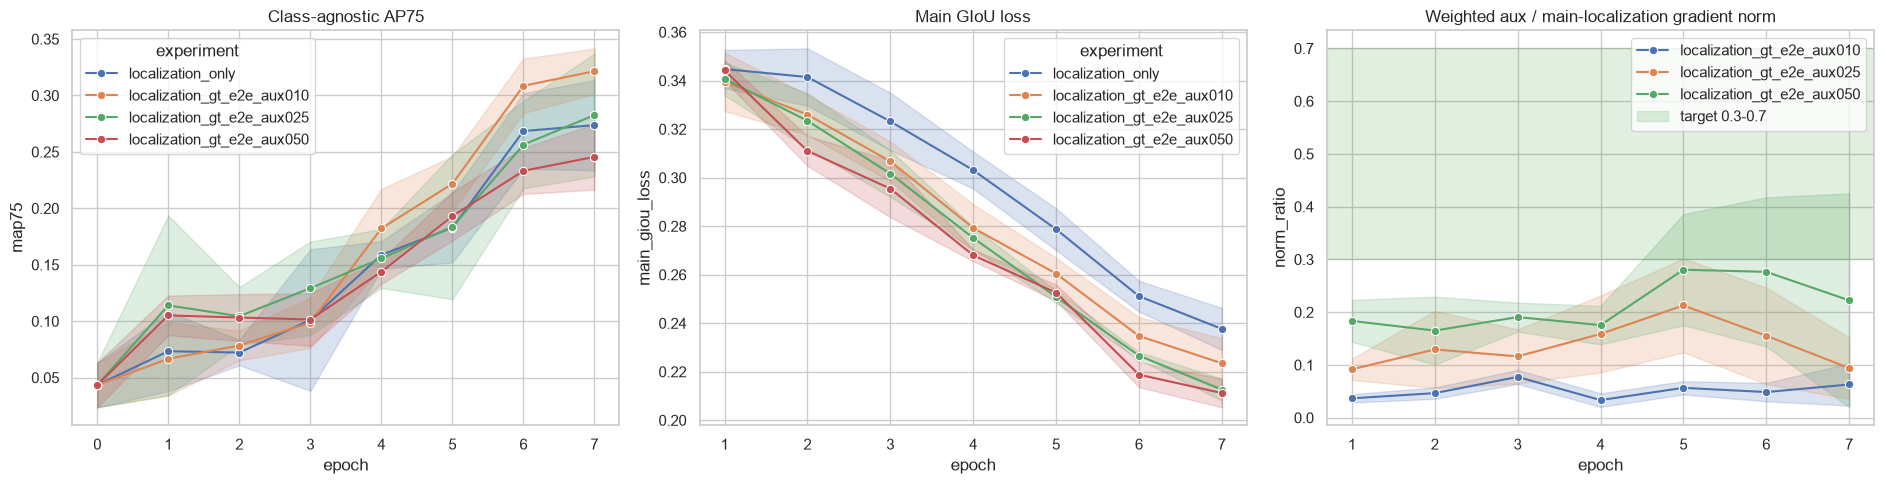

In [14]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.lineplot(data=history_df, x='epoch', y='map75', hue='experiment',
             estimator='mean', errorbar='sd', marker='o', ax=axes[0])
axes[0].set_title('Class-agnostic AP75')
trained = history_df.query('epoch > 0')
sns.lineplot(data=trained, x='epoch', y='main_giou_loss', hue='experiment',
             estimator='mean', errorbar='sd', marker='o', ax=axes[1])
axes[1].set_title('Main GIoU loss')
if not gradient_df.empty:
    sns.lineplot(data=gradient_df, x='epoch', y='norm_ratio', hue='experiment',
                 estimator='mean', errorbar='sd', marker='o', ax=axes[2])
    axes[2].axhspan(0.3, 0.7, color='green', alpha=0.12, label='target 0.3-0.7')
    axes[2].legend()
axes[2].set_title('Weighted aux / main-localization gradient norm')
plt.tight_layout()
figure_path = CONFIG.output_dir / 'localization_only_training_curves.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
print('Saved:', figure_path)
plt.show()

학습 후 `10_evaluate_localization_only_gt_e2e.ipynb`에서 기존 `baseline`, `shared_e2e`와 모든 모델을 동일한 class-agnostic localization protocol로 다시 평가합니다. 학습 history의 mAP는 localization-only 실험 내부 수렴 확인용입니다.